<a href="https://colab.research.google.com/github/BearBearOneBear/Course_ML_Unsupervised_Learning/blob/main/MLassign2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import time

import numpy as np
from torch.utils.data import DataLoader
import pandas as pd

from sklearn import metrics
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN

import matplotlib.pyplot as plt
import seaborn as sns
from torchvision import datasets, transforms

In [2]:
# ==========================================================================
# 1. Data load
# ==========================================================================

def load_data():
    Fashion_mnist_test_transform = transforms.Compose(
        [transforms.ToTensor()]
    )

    testset_Fashion_mnist = datasets.FashionMNIST(
        root='./data',
        train=False,
        download=True,
        transform=Fashion_mnist_test_transform
    )

    FM_test = DataLoader(
        testset_Fashion_mnist,
        batch_size=32,
        shuffle=False,
        num_workers=2
    )

    FM_test_images = []
    FM_test_labels = []

    for batch in FM_test:
        images, labels=batch
        images_flat=images.view(images.shape[0], -1)
        FM_test_images.append(images_flat.numpy())
        FM_test_labels.append(labels.numpy())
    FM_test_images=np.vstack(FM_test_images)
    FM_test_labels=np.concatenate(FM_test_labels)

    X_=pd.DataFrame(data=FM_test_images)
    y_=pd.Series(data=FM_test_labels)

    print("Data loaded successfully.")
    print("X shape:", X_.shape)
    print("y shape:", y_.shape)

    return X_, y_

In [3]:
# ==========================================================================
# 2. PCA
# ==========================================================================

def principal_component_analysis(X_, y_, n_components):
    pca = PCA(n_components)
    test_PCA = pca.fit_transform(X_)
    test_PCA = pd.DataFrame(data=test_PCA)

    testDF=pd.DataFrame(data=test_PCA.loc[:, 0:1], index=test_PCA.index)
    testDF=pd.concat((testDF, y_), axis=1, join="inner")
    testDF.columns=["x-axis", "y-axis", "Label"]
    sns.lmplot(
        x="x-axis",
        y="y-axis",
        hue="Label",
        data=testDF,
        fit_reg=False,
        height=8
    )
    plt.grid()

    plt.show()

    return test_PCA

In [4]:
# ==========================================================================
# 3. ARI
# ==========================================================================

def adjusted_rand_index(y_, cluster_labels):
    ari = metrics.adjusted_rand_score(y_, cluster_labels)

    return ari

In [5]:
# ==========================================================================
# 4. K-means clustering
# ==========================================================================

def k_means_clustering(
    X_,
    clusters=10,
    max_iter=100,
    n_init=5,
    tol=1e-4,
    random_state=42
):

    X = np.asarray(X_, dtype=np.float32)

    model = KMeans(
        n_clusters=clusters,
        init="k-means++",
        n_init=n_init,
        max_iter=max_iter,
        tol=tol,
        random_state=random_state
    )

    cluster_labels = model.fit_predict(X)

    return cluster_labels


In [6]:
# ==========================================================================
# 5. DBSCAN clustering
# ==========================================================================

def dbscan_clustering(X_, eps, min_neighbors):

    X = np.asarray(X_, dtype=np.float32)

    model = DBSCAN(
        eps=eps,
        min_samples=min_neighbors,
        metric="euclidean",
        n_jobs=-1
    )

    cluster_labels = model.fit_predict(X)

    return cluster_labels

def dbscan_grid_search(X_, y_, dim, eps_list, min_neighbor_list):

    best_ari = 0
    best_result = None
    best_labels = None
    grid_results = []

    for eps in eps_list:
        for min_neighbors in min_neighbor_list:
            print()
            print("-" * 60)
            print(f"DBSCAN trial | dim={dim}, eps={eps}, min_neighbors={min_neighbors}")

            start_time = time.time()

            cluster_labels = dbscan_clustering(
                X_,
                eps=eps,
                min_neighbors=min_neighbors
            )

            end_time = time.time()
            elapsed = end_time - start_time

            ari = adjusted_rand_index(y_, cluster_labels)

            n_clusters = len(set(cluster_labels)) - (1 if -1 in cluster_labels else 0)
            n_noise = np.sum(cluster_labels == -1)
            noise_ratio = n_noise / len(cluster_labels)

            result = {
                "Algorithm": "DBSCAN",
                "Dim": dim,
                "ARI": ari,
                "Time": elapsed,
                "eps": eps,
                "min_neighbors": min_neighbors,
                "n_clusters": n_clusters
            }

            grid_results.append(result)

            print(
                f"ARI={ari:.4f} | clusters={n_clusters} | "
                f"noise={n_noise} ({noise_ratio:.3f}) | time={elapsed:.2f}s"
            )
            print("-" * 60)

            if n_clusters > 1 and ari > best_ari:
                best_ari = ari
                best_result = result
                best_labels = cluster_labels.copy()

    print()
    print("-" * 60)
    print(f"Best result | dim={dim} | eps={best_result['eps']} | min_neighbors={best_result['min_neighbors']}")
    print(f"ARI={best_result['ARI']:.4f} | clusters={best_result['n_clusters']} | time={best_result['Time']:.2f}s")

    return best_result, best_labels, grid_results


In [7]:
# ==========================================================================
# 6. Sampling
# ==========================================================================

def sample_for_visualization(X_, labels_, sample_size):
    X = np.asarray(X_, dtype=np.float32)
    labels = np.asarray(labels_)

    n_samples = X.shape[0]
    sample_size = min(sample_size, n_samples)

    random_state = 42
    rng = np.random.default_rng(random_state)
    sampled_indices = rng.choice(n_samples, size=sample_size, replace=False)

    X_sample = X[sampled_indices]
    label_sample = labels[sampled_indices]

    return X_sample, label_sample

In [8]:
# ==========================================================================
# 7. t-SNE
# ==========================================================================

def t_stochastic_neighbor_embedding(X_, best_labels, sample_size=100):
    X_sample, label_sample = sample_for_visualization(
        X_,
        best_labels,
        sample_size=sample_size
    )

    n_components=2
    learning_rate=300
    perplexity=30
    early_exaggeration=12
    init="random"

    tSNE=TSNE(
        n_components=n_components,
        learning_rate=learning_rate,
        perplexity=perplexity,
        early_exaggeration=early_exaggeration,
        init=init
    )

    X_test_tSNE=tSNE.fit_transform(X_sample)
    X_test_tSNE=pd.DataFrame(data=X_test_tSNE)
    testDF=pd.DataFrame(data=X_test_tSNE.loc[:, :], index=X_test_tSNE.index)
    testDF=pd.concat((testDF, pd.Series(label_sample)), axis=1, join="inner")
    testDF.columns=["x-axis", "y-axis", "Label"]

    sns.lmplot(
        x="x-axis",
        y="y-axis",
        hue="Label",
        data=testDF,
        fit_reg=False,
        height=8
    )
    plt.title("Clustering Result")
    plt.grid()

    plt.show()

    return

In [9]:
# ==========================================================================
# 8. Experiment
# ==========================================================================

def experiment():
    # sample_size
    sample_size = 1000

    results = []
    dbscan_grid_results = []

    # load data
    X_, y_ = load_data()

    # PCA
    X_784 = X_
    X_100 = principal_component_analysis(X_, y_, n_components=100)
    X_50 = principal_component_analysis(X_, y_, n_components=50)
    X_10 = principal_component_analysis(X_, y_, n_components=10)

    datasets = {
        784: X_784,
        100: X_100,
        50: X_50,
        10: X_10
    }

    # k-means
    for dim, X_dim in datasets.items():
        print()
        print("=" * 74)
        print("K-means clustering")

        start_time = time.time()

        cluster_labels = k_means_clustering(
            X_dim,
            clusters=10,
            max_iter=100,
            n_init=5,
            tol=1e-4,
            random_state=42
        )

        end_time = time.time()
        elapsed = end_time - start_time

        ari = adjusted_rand_index(y_, cluster_labels)

        print(f"dimension={dim} | ARI={ari:.4f} | time={elapsed:.2f}s")
        print("=" * 74)

        # t_SNE
        t_stochastic_neighbor_embedding(
            X_dim,
            cluster_labels,
            sample_size=sample_size
        )

        results.append({
            "Algorithm": "K-means",
            "Dim": dim,
            "ARI": round(ari, 4),
            "Time": round(elapsed, 2),
            "Parameters": "k=10, k-means++, n_init=5",
            "n_clusters": 10
        })

    # DBSCAN
    for dim, X_dim in datasets.items():
        print()
        print("=" * 74)
        print("DBSCAN clustering")

        # 차원별 하이퍼 파라미터
        if dim == 784:
            eps_list = [2.5, 3.0, 3.5, 4.0, 4.5, 5.0]
            min_neighbor_list = [10, 15, 20]

        elif dim == 100:
            eps_list = [2.0, 2.5, 3.0, 3.5, 4.0]
            min_neighbor_list = [5, 10, 15, 20]

        elif dim == 50:
            eps_list = [1.5, 2.0, 2.5, 3.0, 3.5]
            min_neighbor_list = [5, 10, 15, 20]

        elif dim == 10:
            eps_list = [0.5, 1.0, 1.5, 2.0, 2.5, 3.0]
            min_neighbor_list = [5, 10, 15]

        best_result, best_labels, grid_results = dbscan_grid_search(
            X_=X_dim,
            y_=y_,
            dim=dim,
            eps_list=eps_list,
            min_neighbor_list=min_neighbor_list
        )

        dbscan_grid_results.extend(grid_results)

        print("=" * 74)

        # t_SNE
        t_stochastic_neighbor_embedding(
            X_dim,
            best_labels,
            sample_size=sample_size
        )

        results.append({
            "Algorithm": "DBSCAN",
            "Dim": dim,
            "ARI": round(best_result["ARI"], 4),
            "Time": round(best_result["Time"], 2),
            "Parameters": (
                f"eps={best_result['eps']}, "
                f"min_neighbors={best_result['min_neighbors']}"
            ),
            "n_clusters": best_result["n_clusters"]
        })

    # results
    result_df = pd.DataFrame(results)
    dbscan_df = pd.DataFrame(dbscan_grid_results)

    print()
    print("=" * 74)
    print("Final Results")
    print("-" * 74)
    print(result_df)
    print("=" * 74)

    print()
    print("=" * 74)
    print("DBSCAN Grid Search Results")
    print("-" * 74)
    print(dbscan_df)
    print("=" * 74)

    return

100%|██████████| 26.4M/26.4M [00:01<00:00, 14.5MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 232kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 4.28MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 11.3MB/s]


Data loaded successfully.
X shape: (10000, 784)
y shape: (10000,)


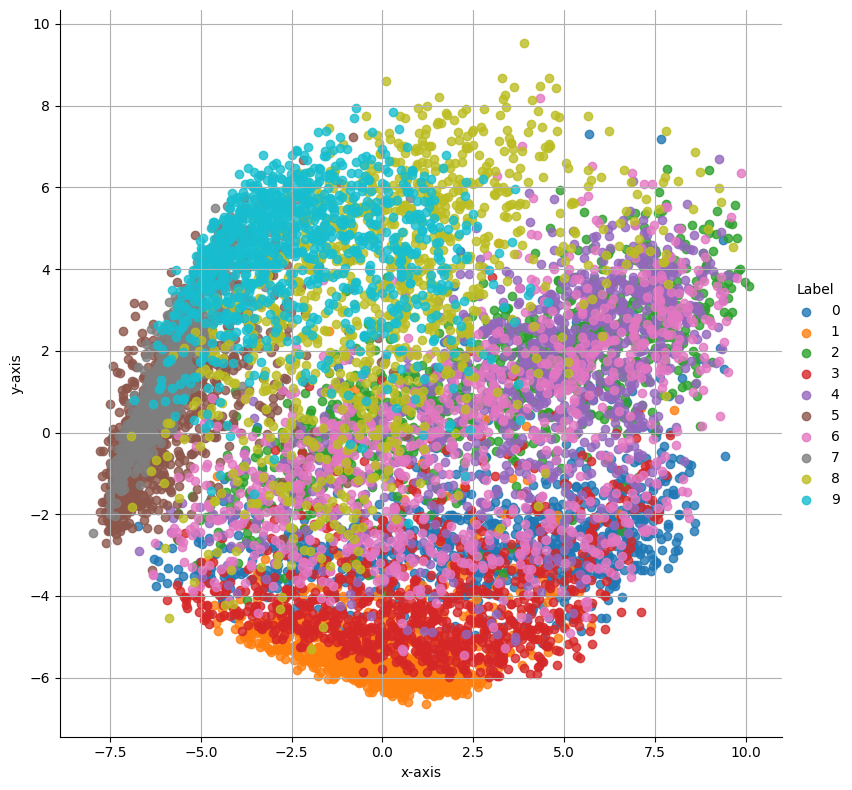

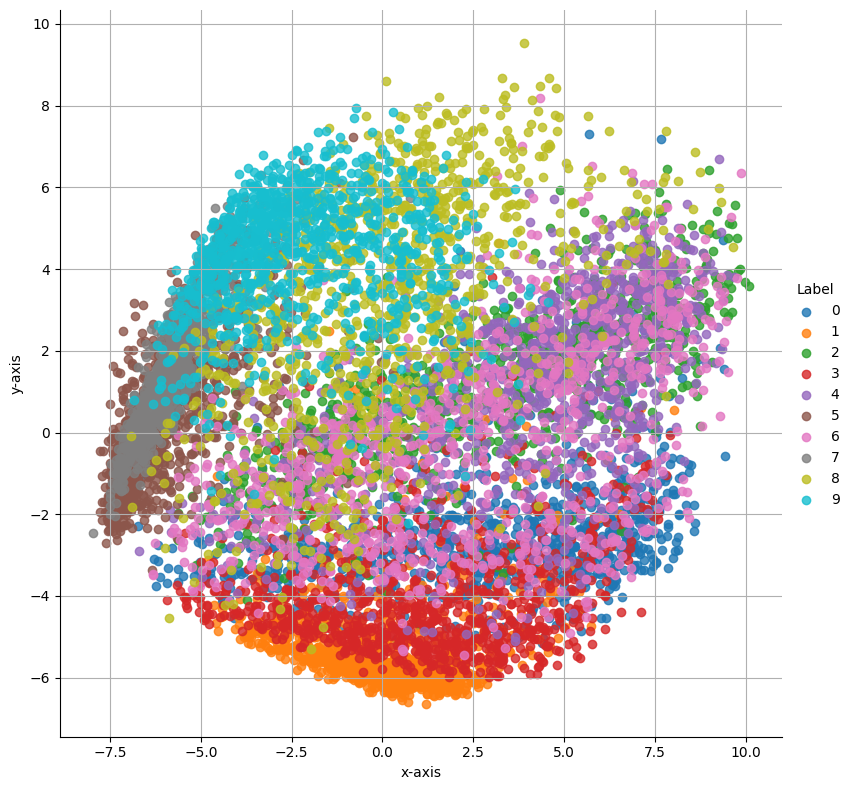

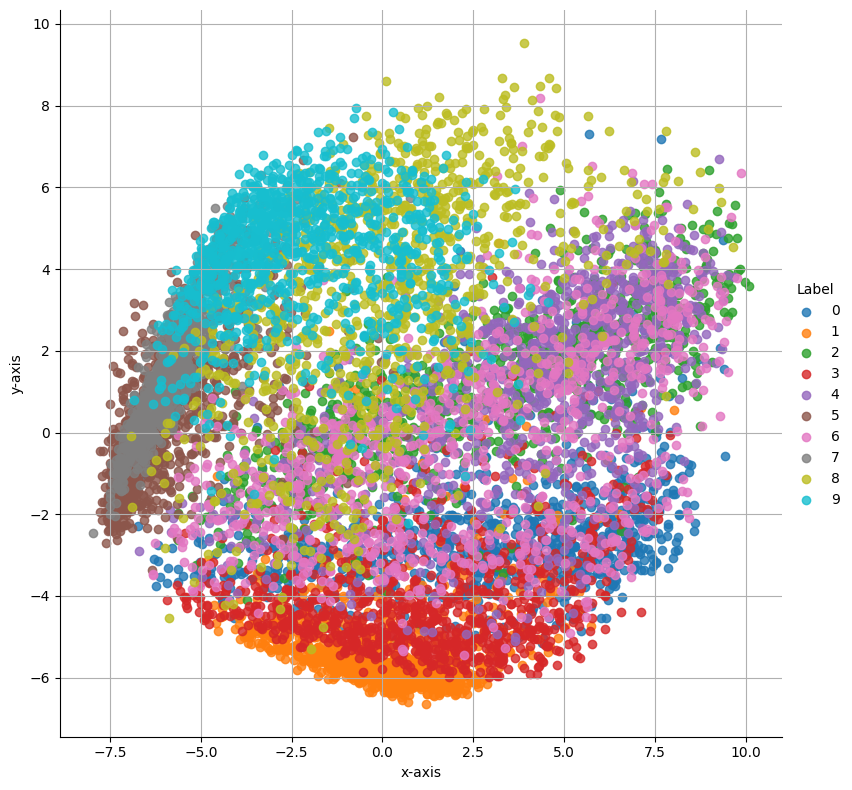


K-means clustering
dimension=784 | ARI=0.3498 | time=5.73s


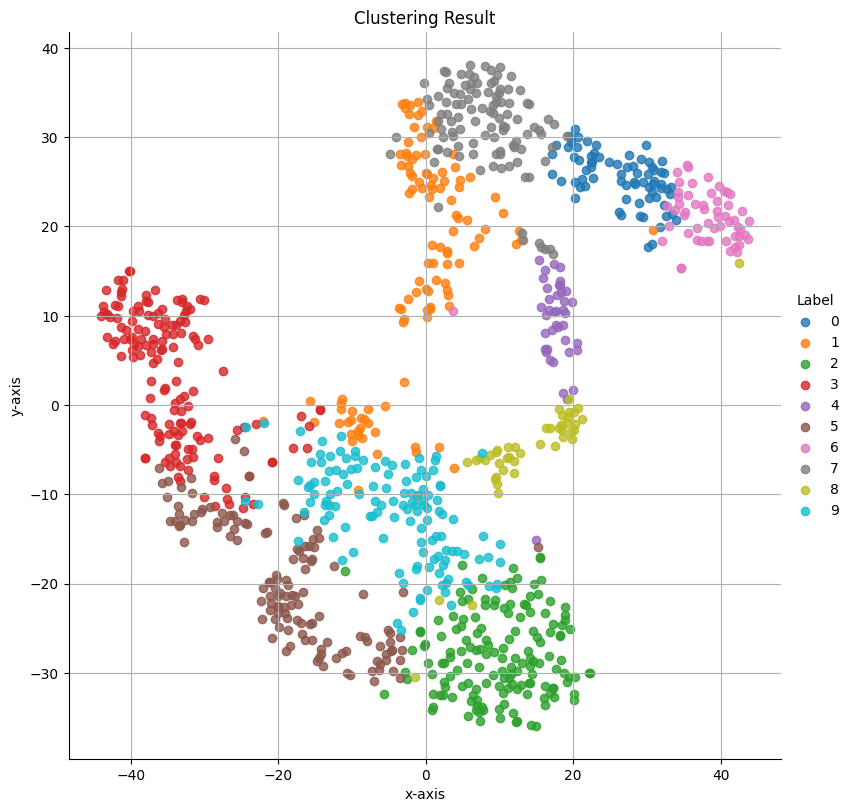


K-means clustering
dimension=100 | ARI=0.3911 | time=0.50s


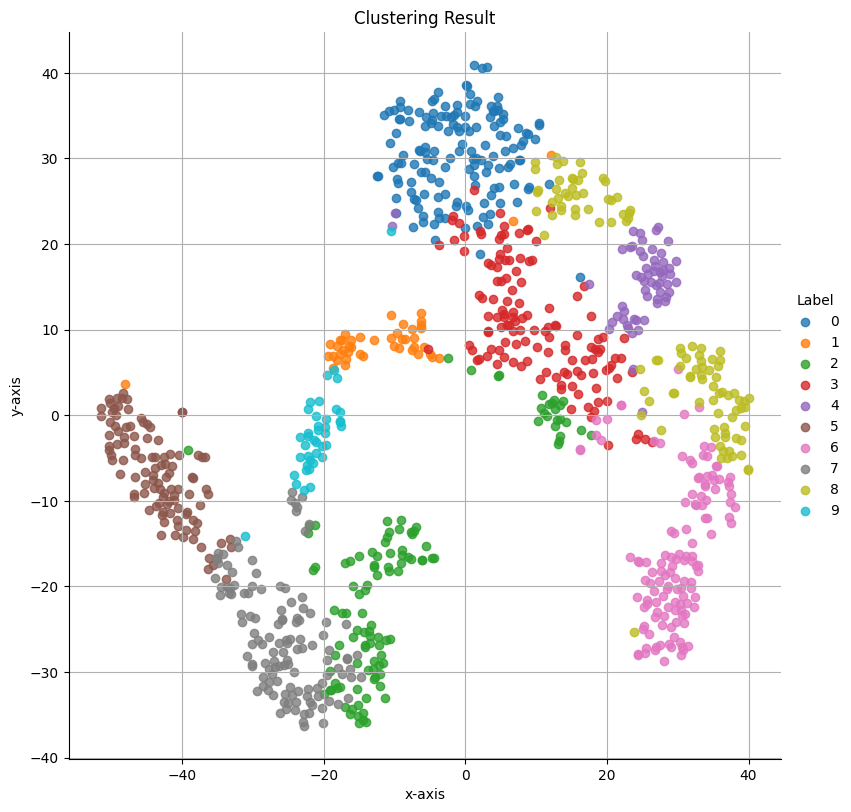


K-means clustering
dimension=50 | ARI=0.3399 | time=0.38s


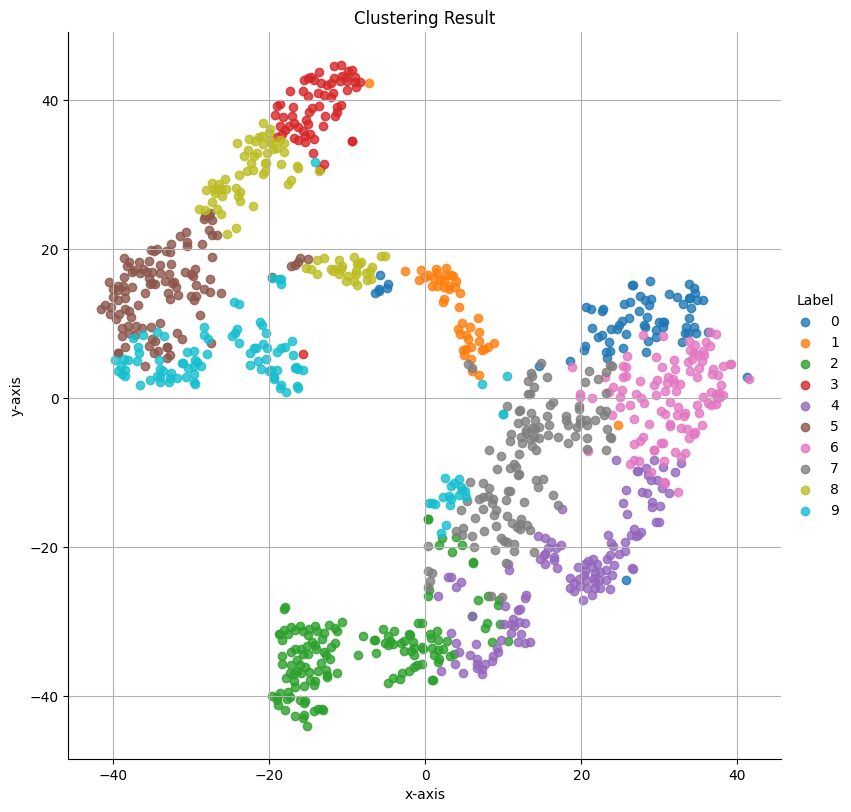


K-means clustering
dimension=10 | ARI=0.3497 | time=0.16s


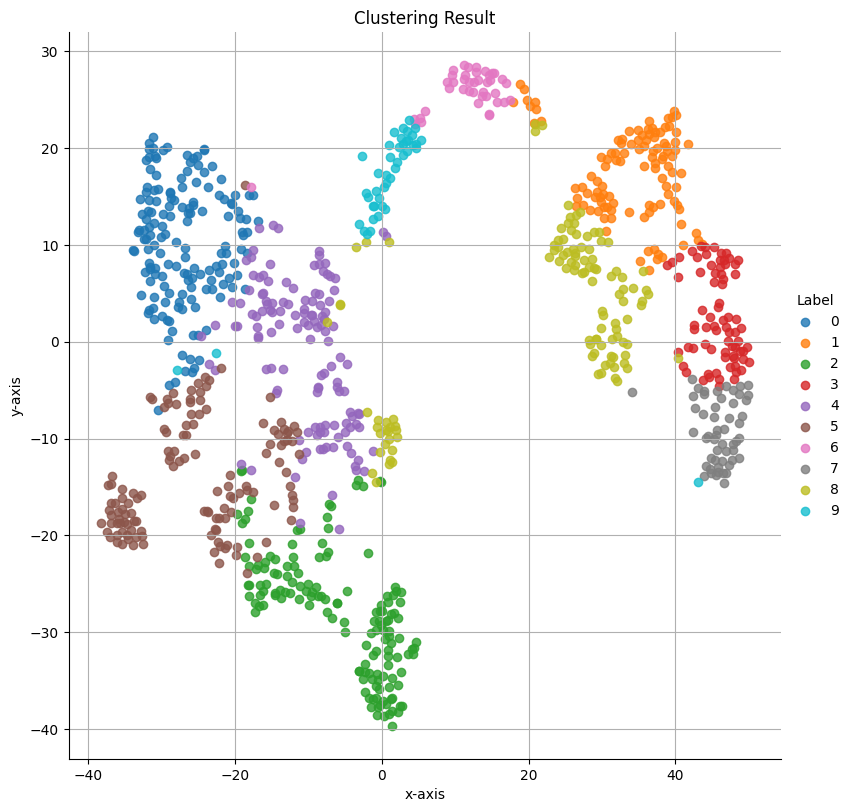


DBSCAN clustering

------------------------------------------------------------
DBSCAN trial | dim=784, eps=2.5, min_neighbors=10
ARI=0.0004 | clusters=5 | noise=9854 (0.985) | time=5.41s
------------------------------------------------------------

------------------------------------------------------------
DBSCAN trial | dim=784, eps=2.5, min_neighbors=15
ARI=0.0001 | clusters=1 | noise=9962 (0.996) | time=6.24s
------------------------------------------------------------

------------------------------------------------------------
DBSCAN trial | dim=784, eps=2.5, min_neighbors=20
ARI=0.0000 | clusters=1 | noise=9979 (0.998) | time=5.95s
------------------------------------------------------------

------------------------------------------------------------
DBSCAN trial | dim=784, eps=3.0, min_neighbors=10
ARI=0.0108 | clusters=9 | noise=9195 (0.919) | time=5.82s
------------------------------------------------------------

--------------------------------------------------------

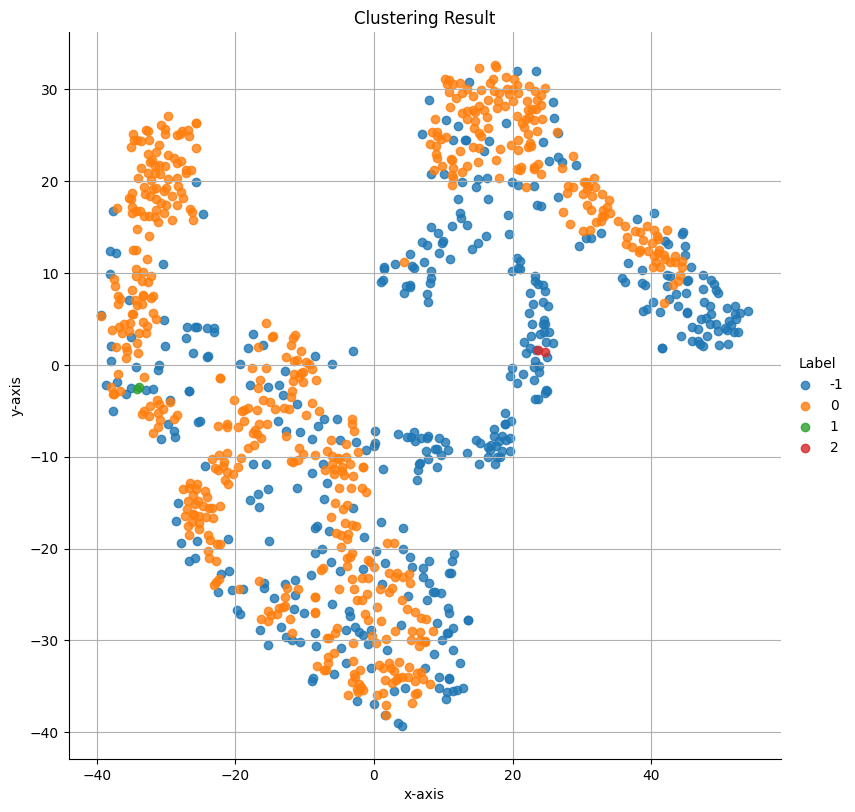


DBSCAN clustering

------------------------------------------------------------
DBSCAN trial | dim=100, eps=2.0, min_neighbors=5
ARI=0.0045 | clusters=29 | noise=9341 (0.934) | time=0.89s
------------------------------------------------------------

------------------------------------------------------------
DBSCAN trial | dim=100, eps=2.0, min_neighbors=10
ARI=0.0007 | clusters=10 | noise=9702 (0.970) | time=0.85s
------------------------------------------------------------

------------------------------------------------------------
DBSCAN trial | dim=100, eps=2.0, min_neighbors=15
ARI=0.0001 | clusters=2 | noise=9919 (0.992) | time=0.83s
------------------------------------------------------------

------------------------------------------------------------
DBSCAN trial | dim=100, eps=2.0, min_neighbors=20
ARI=0.0000 | clusters=1 | noise=9968 (0.997) | time=0.85s
------------------------------------------------------------

-------------------------------------------------------

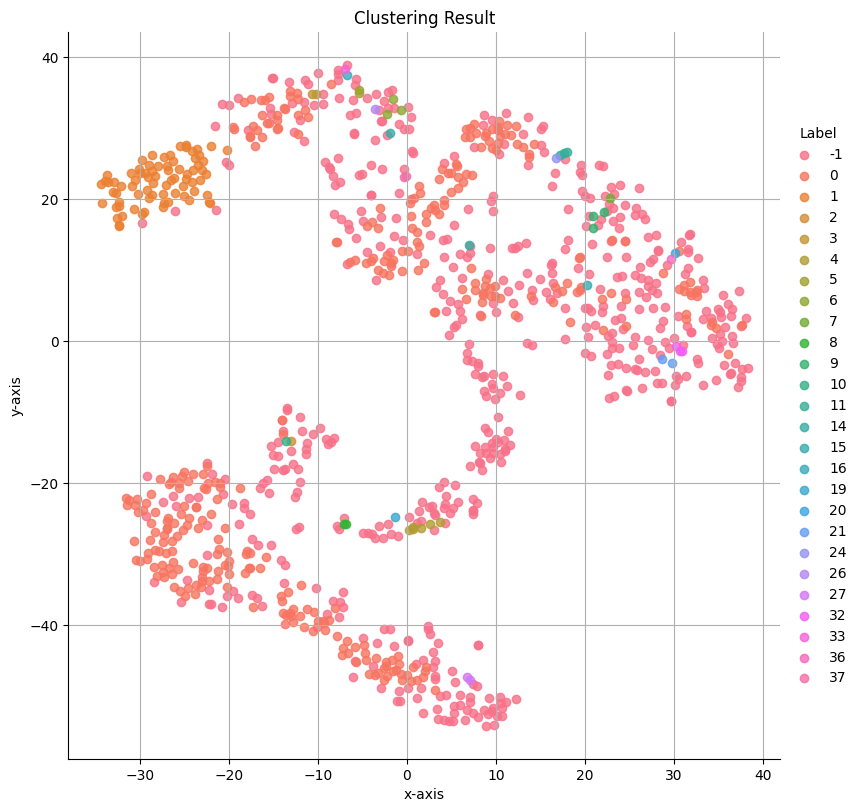


DBSCAN clustering

------------------------------------------------------------
DBSCAN trial | dim=50, eps=1.5, min_neighbors=5
ARI=0.0017 | clusters=30 | noise=9561 (0.956) | time=0.57s
------------------------------------------------------------

------------------------------------------------------------
DBSCAN trial | dim=50, eps=1.5, min_neighbors=10
ARI=0.0003 | clusters=4 | noise=9852 (0.985) | time=0.54s
------------------------------------------------------------

------------------------------------------------------------
DBSCAN trial | dim=50, eps=1.5, min_neighbors=15
ARI=0.0000 | clusters=2 | noise=9960 (0.996) | time=0.53s
------------------------------------------------------------

------------------------------------------------------------
DBSCAN trial | dim=50, eps=1.5, min_neighbors=20
ARI=0.0000 | clusters=0 | noise=10000 (1.000) | time=0.53s
------------------------------------------------------------

-----------------------------------------------------------

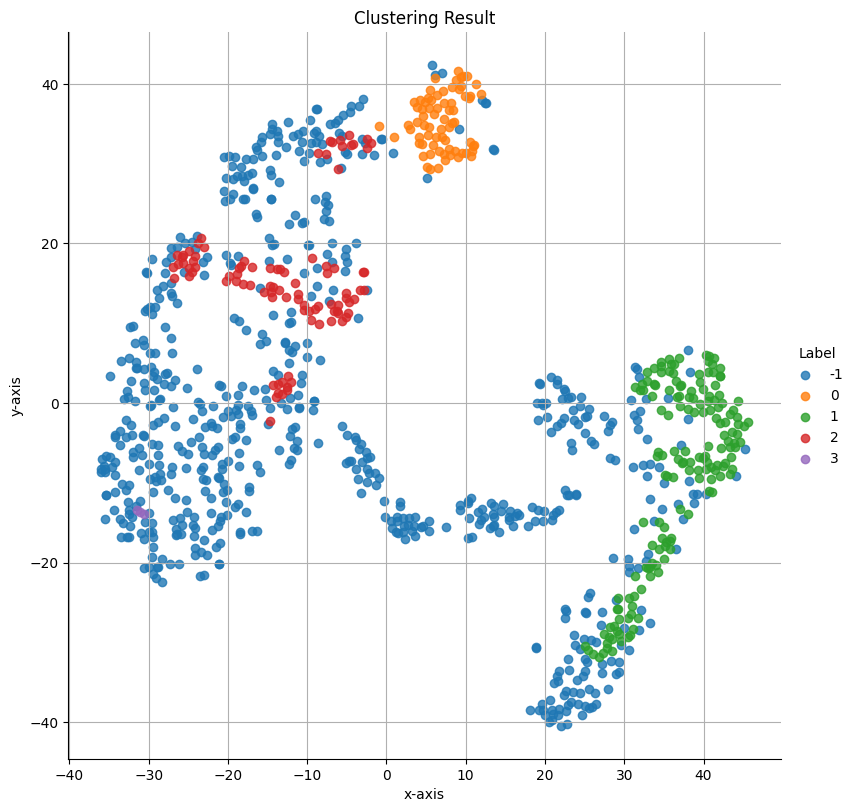


DBSCAN clustering

------------------------------------------------------------
DBSCAN trial | dim=10, eps=0.5, min_neighbors=5
ARI=0.0005 | clusters=23 | noise=9774 (0.977) | time=0.22s
------------------------------------------------------------

------------------------------------------------------------
DBSCAN trial | dim=10, eps=0.5, min_neighbors=10
ARI=0.0000 | clusters=2 | noise=9960 (0.996) | time=0.18s
------------------------------------------------------------

------------------------------------------------------------
DBSCAN trial | dim=10, eps=0.5, min_neighbors=15
ARI=0.0000 | clusters=0 | noise=10000 (1.000) | time=0.19s
------------------------------------------------------------

------------------------------------------------------------
DBSCAN trial | dim=10, eps=1.0, min_neighbors=5
ARI=0.0817 | clusters=52 | noise=6701 (0.670) | time=0.29s
------------------------------------------------------------

-----------------------------------------------------------

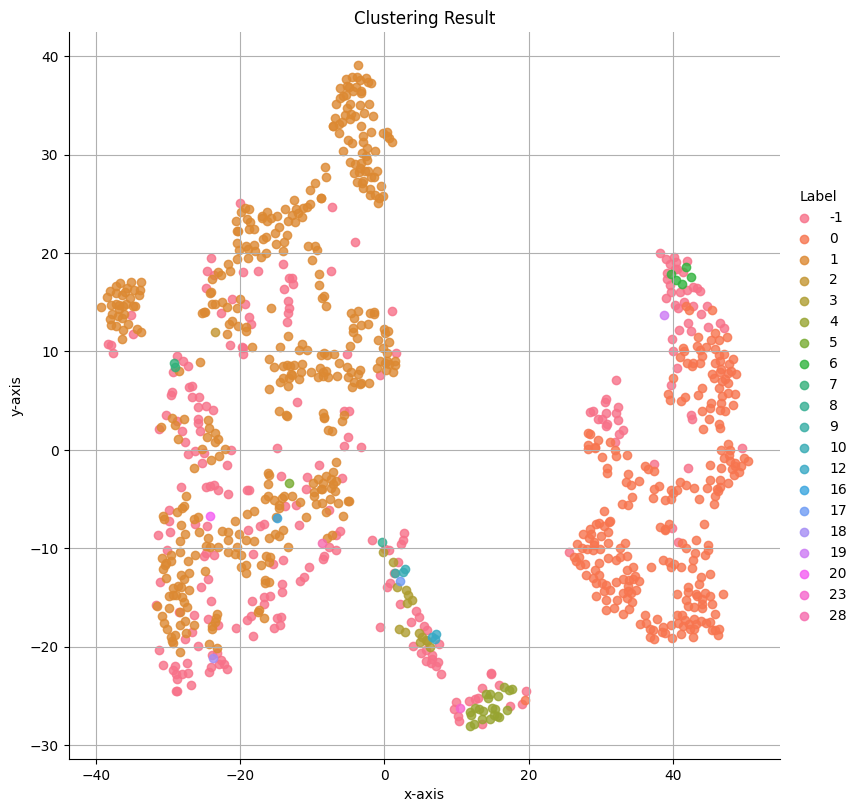


Final Results
--------------------------------------------------------------------------
  Algorithm  Dim     ARI  Time                 Parameters  n_clusters
0   K-means  784  0.3498  5.73  k=10, k-means++, n_init=5          10
1   K-means  100  0.3911  0.50  k=10, k-means++, n_init=5          10
2   K-means   50  0.3399  0.38  k=10, k-means++, n_init=5          10
3   K-means   10  0.3497  0.16  k=10, k-means++, n_init=5          10
4    DBSCAN  784  0.0476  5.53  eps=4.5, min_neighbors=15           3
5    DBSCAN  100  0.0755  0.86   eps=3.0, min_neighbors=5          38
6    DBSCAN   50  0.0822  0.93  eps=2.5, min_neighbors=15           4
7    DBSCAN   10  0.1722  0.40   eps=1.5, min_neighbors=5          29

DBSCAN Grid Search Results
--------------------------------------------------------------------------
   Algorithm  Dim       ARI      Time  eps  min_neighbors  n_clusters
0     DBSCAN  784  0.000394  5.405207  2.5             10           5
1     DBSCAN  784  0.000057  6.242548

In [10]:
# ==========================================================================
# 9. Main
# ==========================================================================

def main():
    experiment()
    return

main()